In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [4]:
file_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "pavansubhasht/ibm-hr-analytics-attrition-dataset",
    file_path
)

df.head()
df.info()
df.describe()
df.select_dtypes(include=["int64","float64"]).columns
df.select_dtypes(include=["object"]).columns
print(df.shape)

/tmp/ipykernel_975/31643021.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   i

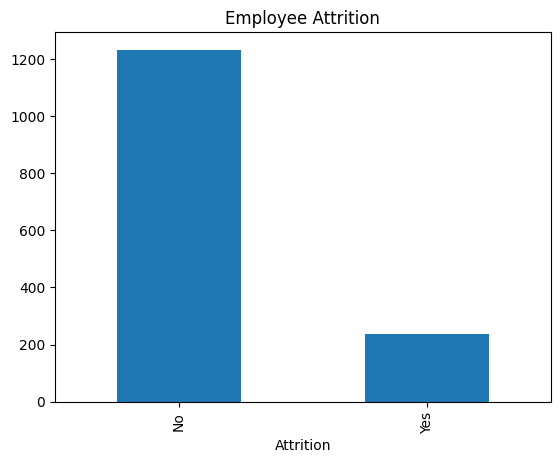

In [5]:
df["Attrition"].value_counts().plot(kind="bar")
plt.title("Employee Attrition")
plt.show()


In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print("Missing Values:\n")
print(df.isnull().sum())

# 2. Remove unnecessary columns (if they exist)
columns_to_drop = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]

for col in columns_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# 3. Encode all categorical variables
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

# 4. Select features and target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# 5. Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


Missing Values:

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion

In [15]:
dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

dt_pred=dt.predict(X_test)
rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred=rf.predict(X_test)
print("Decision Tree")

print("Accuracy :",accuracy_score(y_test,dt_pred))
print("Precision :",precision_score(y_test,dt_pred))
print("Recall :",recall_score(y_test,dt_pred))
print("F1 :",f1_score(y_test,dt_pred))

print(classification_report(y_test,dt_pred))

Decision Tree
Accuracy : 0.7993197278911565
Precision : 0.23684210526315788
Recall : 0.23076923076923078
F1 : 0.23376623376623376
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       255
           1       0.24      0.23      0.23        39

    accuracy                           0.80       294
   macro avg       0.56      0.56      0.56       294
weighted avg       0.80      0.80      0.80       294



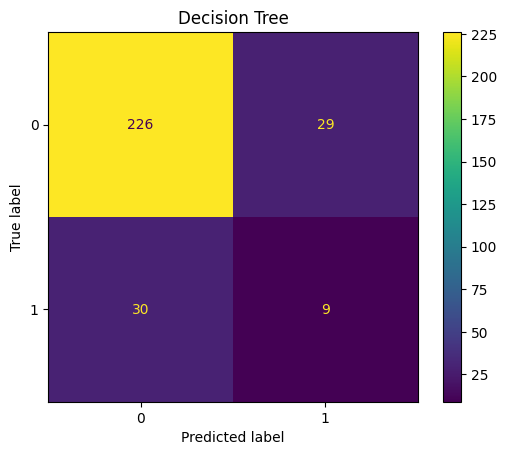

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred
)

plt.title("Decision Tree")

plt.show()

In [17]:
print("Random Forest")

print("Accuracy :",accuracy_score(y_test,rf_pred))
print("Precision :",precision_score(y_test,rf_pred))
print("Recall :",recall_score(y_test,rf_pred))
print("F1 :",f1_score(y_test,rf_pred))

print(classification_report(y_test,rf_pred))

Random Forest
Accuracy : 0.8809523809523809
Precision : 0.8333333333333334
Recall : 0.1282051282051282
F1 : 0.2222222222222222
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       0.83      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.86      0.56      0.58       294
weighted avg       0.88      0.88      0.84       294



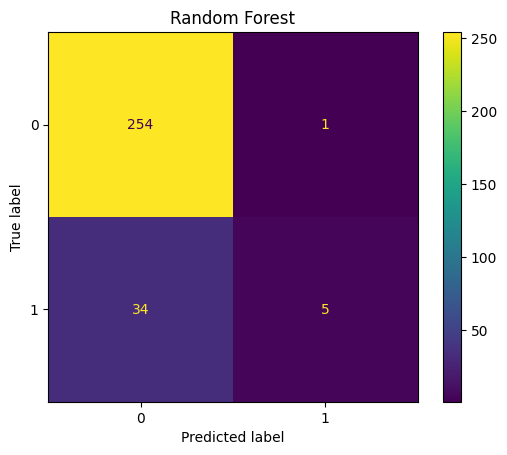

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest")

plt.show()

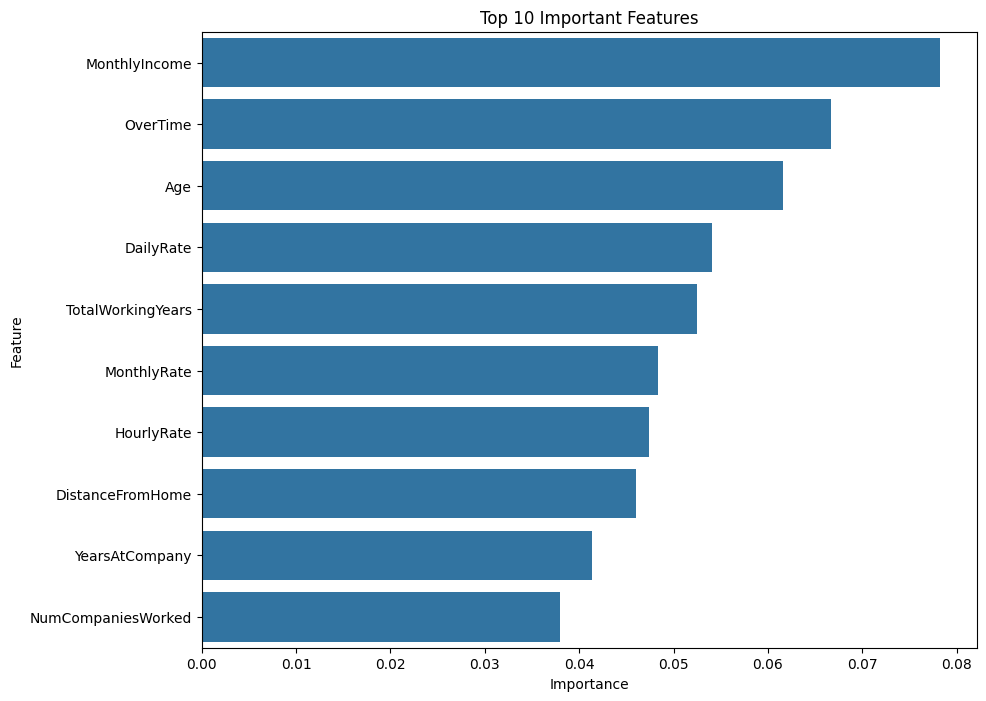

In [19]:
importance=pd.DataFrame({

    "Feature":X.columns,
    "Importance":rf.feature_importances_

})

importance=importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [20]:
rf2=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf2.fit(X_train,y_train)

pred=rf2.predict(X_test)

print(accuracy_score(y_test,pred))

0.8775510204081632
